### Data Loading & Cleaning

In [15]:
# Read data and remove commas, skip header
with open('Data_for_GenAI.csv', 'r') as f:
    data = f.read().splitlines()
smiles = [s.replace(',', '') for s in data][1:]


### Data analysis

In [16]:
print("First 5 SMILES:", smiles[:5])
print("Number of SMILES:", len(smiles))
print("Min SMILES length:", min(len(w) for w in smiles))
print("Max SMILES length:", max(len(w) for w in smiles))

First 5 SMILES: ['Ic1ccc(nc1)Cc1cccc(c1)Cc1ccc(cn1)N1C(=O)c2c(C1=O)cc(cc2)c1ccc2c(c1)C(=O)N(C2=O)I', 'Ic1ccc(nc1)Cc1ccc2c(c1)cc(cc2)Cc1ccc(cn1)N1C(=O)c2c(C1=O)cccc2c1ccc2c(c1)C(=O)N(C2=O)I', 'O=C1c2cc(ccc2C(=O)N1c1ccc(c(c1Cl)Cl)S(=O)(=O)c1ccc2c(c1)c1cc(ccc1C2(C)C)S(=O)(=O)c1ccc(c(c1Cl)Cl)I)c1ccc2c(c1)C(=O)N(C2=O)I', 'Ic1cc(cc(c1)C(=O)O)C(=O)c1ccc2c(c1)ccc(c2)C(=O)c1cc(cc(c1)n1c(=O)c2c(c1=O)cc1c(c2)c(=O)n(c1=O)I)C(=O)O', 'Clc1cc(cc(c1)C(C(F)(F)F)(C(F)(F)F)c1c(C)cc(cc1C)c1cc(C)c(c(c1)C)C(C(F)(F)F)(C(F)(F)F)c1cc(Cl)cc(c1)I)N1C(=O)c2c(C1=O)cccc2c1ccc2c(c1)C(=O)N(C2=O)I']
Number of SMILES: 3000
Min SMILES length: 57
Max SMILES length: 163


### Model Apply

In [17]:
bigrams = {}
for s in smiles:
    chs = ['<S>'] + list(s) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        bigrams[bigram] = bigrams.get(bigram, 0) + 1
# Show most common bigrams
print("Most common bigrams:", sorted(bigrams.items(), key=lambda kv: -kv[1])[:10])


Most common bigrams: [(('c', 'c'), 33383), (('c', '('), 25097), (('c', '1'), 24672), (('(', 'c'), 20672), (('O', ')'), 14882), (('=', 'O'), 14760), (('1', 'c'), 13508), ((')', 'c'), 13373), (('c', '2'), 10854), ((')', 'C'), 10326)]


### Analysing SMILES

In [18]:
import torch

chars = sorted(set(''.join(smiles)))
print("Unique characters:", chars)
print("Number of unique chars:", len(chars))

# Add start/end token '.'
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

Unique characters: ['(', ')', '1', '2', '3', '4', '=', 'C', 'F', 'H', 'I', 'N', 'O', 'S', '[', ']', 'c', 'l', 'n']
Number of unique chars: 19


### Bigram Matrix

In [19]:
N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)
for s in smiles:
    chs = ['.'] + list(s) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1


### Visualization

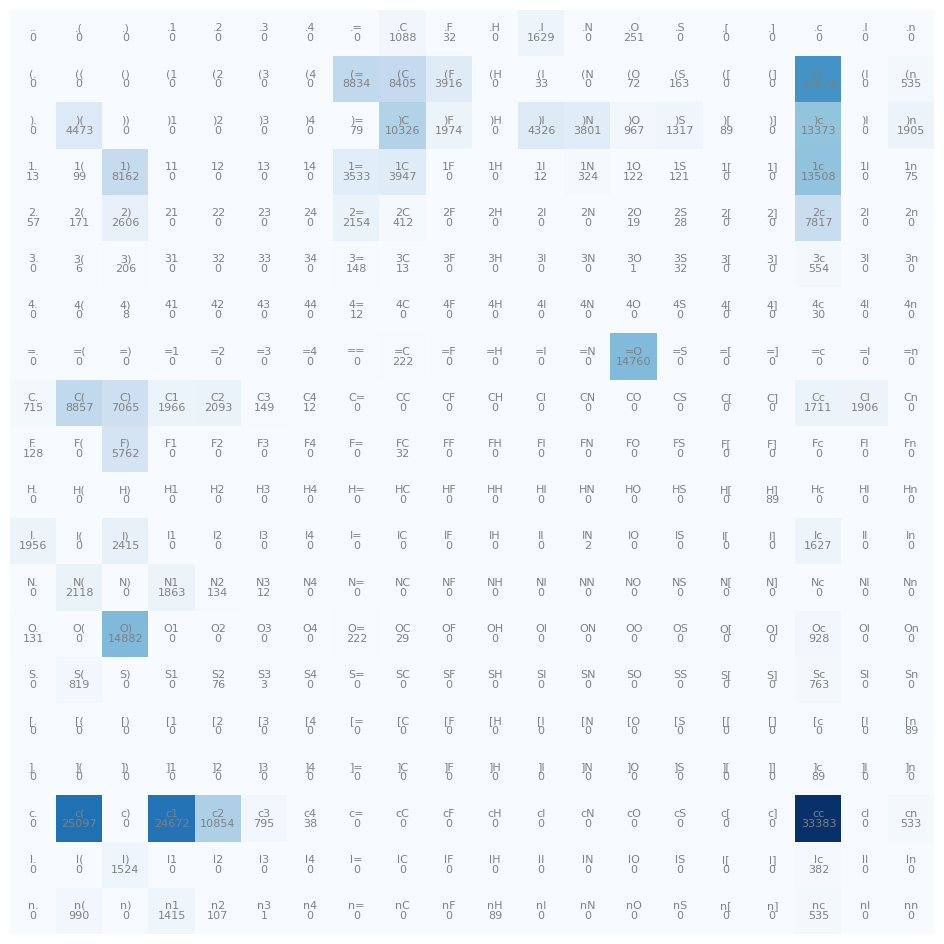

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.imshow(N, cmap='Blues')
for i in range(len(stoi)):
    for j in range(len(stoi)):
        chstr = itos.get(i, '?') + itos.get(j, '?')
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=8)
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray', fontsize=8)
plt.axis('off')
plt.savefig('charmatrix.png')
plt.show()

### Generating New SMILES

In [21]:

P = (N + 1).float()
P /= P.sum(1, keepdims=True)

g = torch.Generator().manual_seed(2147483647)
num_samples = 1000
generated_smiles = []

for _ in range(num_samples):
    out = []
    ix = 0  # Start token index
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:  # End token
            break
    generated_smiles.append(''.join(out[:-1]))  # Remove end token

#print("Sample generated SMILES:", generated_smiles[1:])
generated_smiles

['I',
 'I)(=O)Icc1cc(=O)ccc(C)c(c(F)c1c2=O)n(=O)c(=O)(c2)N(C)c(=O)C)C1=O)I)c(c(n1)C(C)(c2c(cc(C(F)c(=O)c1C(n1)Sc1=O)C(cccc(Cc(c1cc(c(C)C(=O)c(c(c1c(F)c1)(c(c(Clcc1ccc(=O)C)C1C(c1cc(=O)C(c2c1)(=Occ1)(F)c(cccc(c(c2c(C(c1C(=O)c1C(c(=O)N1C2Cl)ccc2c(n2c2)c(c1)c1)Cc2c(F)c(F)C1c1c1C(C2=O)c1)Cl)c(ccccc4=O)F)N1=O)cc1c(c(C)ccc(=O)C)I',
 'I',
 'O)O)N(ccc1cc(ccc1c(c2)cc1)(c(F)C(F)F)c(c(c2c(c2C1ccc(Sc2cc1cc1c(ccc(cc1=O)n(=O)C1C(c2cc(cc1cc1)c2cc(S(cc(=O)n1)ccccc2=O)c1C)N(c1c1c(cccc(=O)(c2)cc(cc(F)ccc2c(c(=O)N2c2c2=O)I)(c1c1)C(c2=O)C(c1N(c2c(=O)cc(C)C2c(c1c1)(C1C',
 'Cl)c(c1O)cc(Cc2=O)C44c1ccc(Cl)I',
 'I)O)N2cc1c2cccc2cc1c1Cc1cn1c2c1c1)c2c1=O)n(c(=O)c2cc2c(c1cc1=O)(=O)Clc1c1)(C)C(=O)C2ccc(ccccc(c(C)N3c1C1c2c(C)n1)N1c2cc2c(=O)c(C(C)(=O)cc1C)C(F',
 'Ic(c(cc1c1(c(ccc(c1c(cc1=O)I)(=O)c1c(=O)N(=O)Ic2cc(cc(=O)(F)C1c(cc(F)I)I)N(c1=O)c(=O)(F)n1)F)C(c(c2cc2c(C)I)Ic1(=O)c2c2)I)n(c1)Cc1=O)c(F)N(C)c1=O)N(=O)cc2)C)Cl)C)c(F)C1c1c(=O)Cccc(c1ccccc2ccc2)C(=O)F)c1c1)n(c2)c1c1ccc1C)(C)(=O)C(F)c(cc1)c(C(C(C(c(C)c2c1cc1c

### Similarity

In [27]:
import sys
import subprocess
try:
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem
    from rdkit import RDLogger
    RDLogger.DisableLog('rdApp.*') 
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit-pypi"])
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem

import numpy as np

def smiles_to_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, n_bits)

# Fingerprints for generated molecules
generated_fps = []
for smi in generated_smiles:
    fp = smiles_to_fingerprint(smi)
    if fp is not None:
        generated_fps.append(fp)
        if len(generated_fps) == 100:
            break

# Fingerprints for original molecules
original_fps = []
for smi in smiles:
    fp = smiles_to_fingerprint(smi)
    if fp is not None:
        original_fps.append(fp)

print("Number of valid generated fingerprints:", len(generated_fps))

# Compute Tanimoto similarities
tanimoto_similarities = []
for gen_fp in generated_fps:
    similarities = DataStructs.BulkTanimotoSimilarity(gen_fp, original_fps)
    tanimoto_similarities.append(np.max(similarities))

# Statistics
avg_similarity = np.mean(tanimoto_similarities)
median_similarity = np.median(tanimoto_similarities)
min_similarity = np.min(tanimoto_similarities)
max_similarity = np.max(tanimoto_similarities)

print(f"Avg Tanimoto: {avg_similarity:.3f}, Median: {median_similarity:.3f}, Min: {min_similarity:.3f}, Max: {max_similarity:.3f}")


Number of valid generated fingerprints: 100
Avg Tanimoto: 0.026, Median: 0.025, Min: 0.000, Max: 0.137


### Plot Similarity Distribution

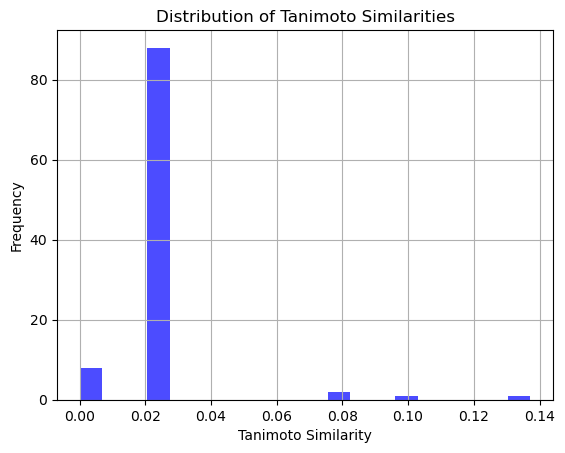

In [28]:
plt.hist(tanimoto_similarities, bins=20, alpha=0.7, color='blue')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Tanimoto Similarities')
plt.grid(True)
plt.savefig('tanimotosim.png')
plt.show()

In [29]:
import joblib

# Save everything the app needs — no .pt file required
# The entire "model" is just the probability matrix + character mappings
model_data = {
    "N": N,           # bigram count matrix (torch tensor)
    "stoi": stoi,     # char → index
    "itos": itos,     # index → char
}
joblib.dump(model_data, "bigram_model.pkl")
print("✅ bigram_model.pkl saved")

✅ bigram_model.pkl saved
